In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ONLY Comm Measurements
# num_devices -> {num_calls: int, mes: [joules_spent_0, joules_spend_1, ...]}
# fuck me why did i think num_calls would be different, its just materializing over more partial computations
comm_measurements = {
    1: {'num_calls': 1176, 'mes': [0.0]},
    2: {'num_calls': 1176, 'mes': [89.3604666, 95.6027066]},
    4: {'num_calls': 1176, 'mes': [283.968006666, 254.55983999999998, 303.533073332, 241.61777997999997]},
    8: {'num_calls': 1176, 'mes': [587.4545532, 779.0089565999999, 619.981496, 680.3964566, 570.27619, 550.06875, 722.4183332, 610.9484966]}
}

In [5]:
step_measurments = {
    # calls come from invocations even with no one to communicate with in the group
    1: {"mes": [232.937833]},
    2: {"mes": [246.52383, 229.21983]},
    4: {"mes": [342.95066666, 382.291333, 353.83650, 379.057333]},
    8: {"mes": [776.670000, 725.2643, 624.95349, 639.79300, 574.44433, 673.66616, 633.885333, 592.952166]},
}

In [7]:
comm_measures = np.array([
    np.array(v['mes']).mean(-1)
    for k, v in comm_measurements.items()
])
step_measures = np.array([
    np.array(v['mes']).mean(-1)
    for k, v in step_measurments.items()
])

bins = list(comm_measurements.keys())
bars = {
    "Comm": comm_measures,
    "Comp": step_measures - comm_measures,
}

In [8]:
bars

{'Comm': array([  0.        ,  92.4815866 , 270.91967499, 640.06915402]),
 'Comp': array([232.937833  , 145.3902434 ,  93.61428317,  15.13444335])}

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (23,) and arg 1 with shape (4,).

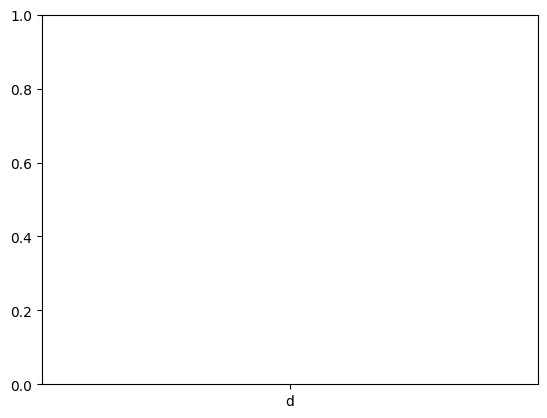

In [ ]:
x = [str(x) for x in step_measurments.keys()]
fig, ax = plt.subplots()
bottom = np.zeros(4)

for boolean, weight_count in bars.items():
    p = ax.bar(x, weight_count, label=boolean, bottom=bottom)
    bottom += weight_count

ax.set_title("AAAAA")
ax.legend()

plt.show()

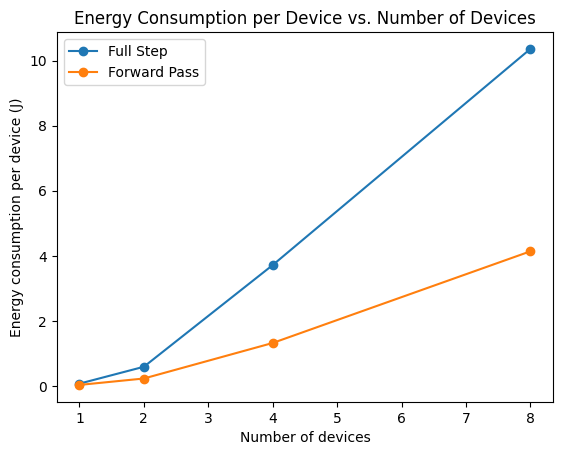

In [ ]:
x = list(no_shard_fwd.keys())

y1 = [np.average(v) for k, v in full_step_data.items()]
y2 = [np.average(v) for k, v in fwd_pass_data.items()]
plt.plot(x, y1, marker='o', label='Full Step')
plt.plot(x, y2, marker='o', label='Forward Pass')
plt.title("Energy Consumption per Device vs. Number of Devices")
plt.xlabel("Number of devices")
plt.ylabel("Energy consumption per device (J)")
plt.legend()
plt.show()